In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# Removed SelectKBest imports since we aren't using them
from helper_lin import get_all_data, get_mult_data, get_sub_data, get_labels 

labels = get_labels()

def svm_show_results_skf(X_avg, y_avg, task_name):
    # 1. Define Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        # Re-added probability=True so predict_proba() works in the loop
        ('svm', SVC(kernel='linear', C=1.0, probability=True, random_state=42)) 
    ])
    
    # 2. Stratified K Fold Cross-Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    
    for train_idx, test_idx in skf.split(X_avg, y_avg):
        # Fit on training fold
        pipeline.fit(X_avg[train_idx], y_avg[train_idx])
        
        # Predict on testing fold
        predictions = pipeline.predict(X_avg[test_idx])
        probs = pipeline.predict_proba(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        y_probs_all.extend(probs)
    
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)

    # 3. Calculate and Print Metrics
    acc = accuracy_score(y_test_all, y_pred_all)
    
    print(f"\n{'='*120}")
    print(f"{task_name} (Averaged) Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))

    # 4. Plotting Confusion Matrix
    plt.figure(figsize=(5, 4))
    # FIX: Use y_test_all here, NOT y_avg, so the shuffled indices match
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Pred TD', 'Pred MLD'], yticklabels=['Actual TD', 'Actual MLD'])
    plt.title(f"{task_name} Confusion Matrix")
    plt.show()

    # 5. Feature Importance (Weights)
    # Fit on the WHOLE dataset to get the final, stable model weights
    pipeline.fit(X_avg, y_avg)
    
    # FIX: Since SelectKBest is gone, we just grab all the weights directly from the SVM.
    weights = pipeline.named_steps['svm'].coef_[0]
    
    # Map to ROI pairs (Schaefer 100 uses upper triangle indices)
    roi_indices = np.triu_indices(100, k=1)
    roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

    print(f"\nTop 10 Strongest Connections for {task_name}:")
    print(f"{'Brain Connection':<55} | {'Weight':<10}")
    print("-" * 70)

    # Sort by absolute weight value (largest to smallest)
    sorted_idx = np.argsort(np.abs(weights))[::-1]

    # Print the top 10 most influential brain connections
    for i in range(10):
        feat_idx = sorted_idx[i]
        roi_a, roi_b = roi_pairs[feat_idx]
        
        name_a = labels[roi_a] 
        name_b = labels[roi_b]
        
        # Clean labels and print
        connection_str = f"{name_a} <-> {name_b}"
        # Print the actual weight (with its positive/negative sign)
        print(f"{connection_str:<55} | {weights[feat_idx]:.4f}") 
    
    return y_test_all, y_pred_all, y_probs_all

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018



All (Averaged) Accuracy: 63.33%
              precision    recall  f1-score   support

          TD       0.64      0.60      0.62        15
         MLD       0.62      0.67      0.65        15

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.63        30
weighted avg       0.63      0.63      0.63        30



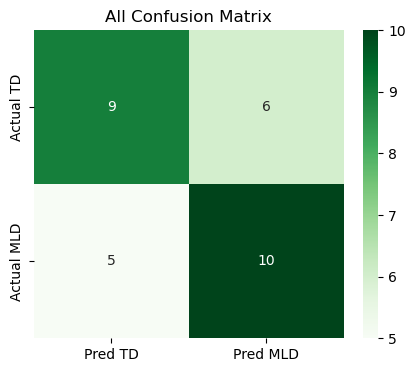


Top 10 Strongest Connections for All:
Brain Connection                                        | Weight    
----------------------------------------------------------------------
7Networks_LH_Vis_8 <-> 7Networks_LH_SomMot_29           | -0.0077
7Networks_LH_SomMot_27 <-> 7Networks_LH_SomMot_36       | -0.0066
7Networks_LH_SomMot_6 <-> 7Networks_LH_SomMot_14        | 0.0062
7Networks_LH_SomMot_27 <-> 7Networks_LH_DorsAttn_Post_3 | -0.0060
7Networks_LH_SomMot_28 <-> 7Networks_LH_DorsAttn_FEF_2  | -0.0057
7Networks_LH_Vis_17 <-> 7Networks_LH_Vis_28             | 0.0057
7Networks_LH_SomMot_28 <-> 7Networks_LH_DorsAttn_Post_11 | -0.0056
7Networks_LH_SomMot_21 <-> 7Networks_LH_DorsAttn_Post_8 | 0.0055
7Networks_LH_SomMot_28 <-> 7Networks_LH_DorsAttn_Post_12 | -0.0055
7Networks_LH_Vis_22 <-> 7Networks_LH_DorsAttn_PrCv_2    | 0.0055


In [36]:
X_avg, y_avg = get_all_data()
y_true, y_pred, y_probs = svm_show_results_skf(X_avg, y_avg, "All")

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from helper_lin import get_all_data, get_mult_data, get_sub_data, get_labels 

labels = get_labels()

def mlp_show_results_skf(X_avg, y_avg, task_name):
    # 1. Define Literature-Backed Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(64, 16), # Funnel architecture for dimensionality reduction
            activation='relu',            # Glorot et al., 2011
            solver='adam',                # Kingma & Ba, 2014
            alpha=0.05,                   # Strong L2 regularization (Weight Decay)
            early_stopping=True,          # Prechelt, 1998 (crucial for neuroimaging data)
            validation_fraction=0.1,      # 10% of training data used to monitor early stopping
            max_iter=1000,                # Give it enough epochs to converge
            random_state=42
        )) 
    ])
    
    # 2. Stratified K Fold Cross-Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    
    for train_idx, test_idx in skf.split(X_avg, y_avg):
        pipeline.fit(X_avg[train_idx], y_avg[train_idx])
        
        predictions = pipeline.predict(X_avg[test_idx])
        probs = pipeline.predict_proba(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        y_probs_all.extend(probs)
    
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)

    # 3. Calculate and Print Metrics
    acc = accuracy_score(y_test_all, y_pred_all)
    
    print(f"\n{'='*120}")
    print(f"{task_name} (MLP Averaged) Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))

    # 4. Plotting Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', # Changed to Blues to differentiate from the SVM's Greens
                xticklabels=['Pred TD', 'Pred MLD'], yticklabels=['Actual TD', 'Actual MLD'])
    plt.title(f"{task_name} MLP Confusion Matrix")
    plt.show()

    # 5. Feature Importance (Heuristic for MLP)
    pipeline.fit(X_avg, y_avg)
    
    # Extract weights from the Input Layer to the First Hidden Layer
    # Shape of coefs_[0] is (n_features, n_hidden_layer_1)
    W1 = pipeline.named_steps['mlp'].coefs_[0]
    
    # Heuristic: Sum the absolute values of the weights for each input feature 
    # across all neurons in the first hidden layer.
    feature_importances = np.sum(np.abs(W1), axis=1)
    
    # Map to ROI pairs
    roi_indices = np.triu_indices(100, k=1)
    roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

    print(f"\nTop 10 Most Influential Connections for {task_name} (MLP W1-Norm Heuristic):")
    print(f"{'Brain Connection':<55} | {'Importance':<10}")
    print("-" * 70)

    # Sort by calculated importance value (largest to smallest)
    sorted_idx = np.argsort(feature_importances)[::-1]

    for i in range(10):
        feat_idx = sorted_idx[i]
        roi_a, roi_b = roi_pairs[feat_idx]
        
        name_a = labels[roi_a] 
        name_b = labels[roi_b]
        
        connection_str = f"{name_a} <-> {name_b}"
        print(f"{connection_str:<55} | {feature_importances[feat_idx]:.4f}") 
    
    return y_test_all, y_pred_all, y_probs_all

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018



All (MLP Averaged) Accuracy: 63.33%
              precision    recall  f1-score   support

          TD       0.64      0.60      0.62        15
         MLD       0.62      0.67      0.65        15

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.63        30
weighted avg       0.63      0.63      0.63        30



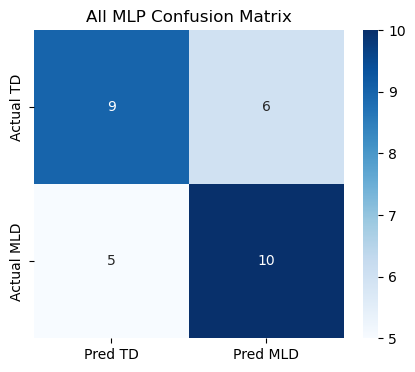


Top 10 Most Influential Connections for All (MLP W1-Norm Heuristic):
Brain Connection                                        | Importance
----------------------------------------------------------------------
7Networks_LH_SomMot_9 <-> 7Networks_LH_SomMot_27        | 1.3979
7Networks_LH_SomMot_9 <-> 7Networks_LH_SomMot_25        | 1.3687
7Networks_LH_Vis_9 <-> 7Networks_LH_SomMot_13           | 1.3544
7Networks_LH_SomMot_16 <-> 7Networks_LH_DorsAttn_Post_5 | 1.3493
7Networks_LH_Vis_14 <-> 7Networks_LH_DorsAttn_Post_10   | 1.3443
7Networks_LH_Vis_24 <-> 7Networks_LH_SomMot_16          | 1.3417
7Networks_LH_SomMot_22 <-> 7Networks_LH_SomMot_32       | 1.3356
7Networks_LH_SalVentAttn_ParOper_4 <-> 7Networks_LH_SalVentAttn_FrOperIns_3 | 1.3340
7Networks_LH_SomMot_9 <-> 7Networks_LH_DorsAttn_Post_17 | 1.3328
7Networks_LH_SomMot_28 <-> 7Networks_LH_SomMot_33       | 1.3325


In [38]:
X_avg, y_avg = get_all_data()
y_true, y_pred, y_probs = mlp_show_results_skf(X_avg, y_avg,"All")

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from helper_lin import get_all_data, get_mult_data, get_sub_data, get_labels 

labels = get_labels()

def xgb_show_results_skf(X_avg, y_avg, task_name):
    # 1. Define Literature-Backed Pipeline
    pipeline = Pipeline([
        # Tree models don't strictly require scaling, but keeping it 
        # ensures consistency across your methodology
        ('scaler', StandardScaler()),
        ('xgb', XGBClassifier(
            max_depth=3,              # Shallow trees to prevent memorization
            learning_rate=0.05,       # Slow, controlled learning
            n_estimators=100,         # Number of trees
            subsample=0.8,            # Use 80% of samples per tree
            colsample_bytree=0.1,     # Aggressive: Use only 10% of features per tree 
            reg_alpha=1.0,            # L1 Regularization (pushes useless weights to 0)
            reg_lambda=1.0,           # L2 Regularization
            eval_metric='logloss',
            random_state=42
        )) 
    ])
    
    # 2. Stratified K Fold Cross-Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    
    for train_idx, test_idx in skf.split(X_avg, y_avg):
        pipeline.fit(X_avg[train_idx], y_avg[train_idx])
        
        predictions = pipeline.predict(X_avg[test_idx])
        probs = pipeline.predict_proba(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        y_probs_all.extend(probs)
    
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)

    # 3. Calculate and Print Metrics
    acc = accuracy_score(y_test_all, y_pred_all)
    
    print(f"\n{'='*120}")
    print(f"{task_name} (XGBoost Averaged) Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))

    # 4. Plotting Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', # Orange to visually separate from SVM and MLP
                xticklabels=['Pred TD', 'Pred MLD'], yticklabels=['Actual TD', 'Actual MLD'])
    plt.title(f"{task_name} XGBoost Confusion Matrix")
    plt.show()

    # 5. Feature Importance (Native to XGBoost)
    pipeline.fit(X_avg, y_avg)
    
    # XGBoost natively calculates the importance of each feature
    feature_importances = pipeline.named_steps['xgb'].feature_importances_
    
    # Map to ROI pairs
    roi_indices = np.triu_indices(100, k=1)
    roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

    print(f"\nTop 10 Most Influential Connections for {task_name} (XGBoost Native Importance):")
    print(f"{'Brain Connection':<55} | {'Importance':<10}")
    print("-" * 70)

    # Sort by calculated importance value (largest to smallest)
    sorted_idx = np.argsort(feature_importances)[::-1]

    for i in range(10):
        feat_idx = sorted_idx[i]
        roi_a, roi_b = roi_pairs[feat_idx]
        
        name_a = labels[roi_a] 
        name_b = labels[roi_b]
        
        connection_str = f"{name_a} <-> {name_b}"
        print(f"{connection_str:<55} | {feature_importances[feat_idx]:.4f}") 
    
    return y_test_all, y_pred_all, y_probs_all

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018



All (XGBoost Averaged) Accuracy: 56.67%
              precision    recall  f1-score   support

          TD       0.56      0.60      0.58        15
         MLD       0.57      0.53      0.55        15

    accuracy                           0.57        30
   macro avg       0.57      0.57      0.57        30
weighted avg       0.57      0.57      0.57        30



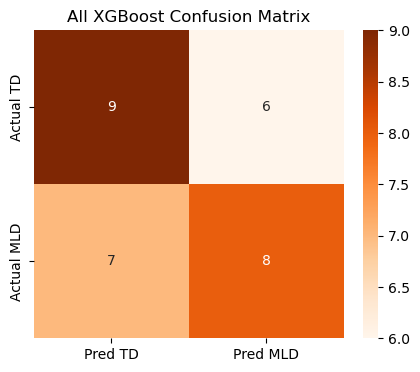


Top 10 Most Influential Connections for All (XGBoost Native Importance):
Brain Connection                                        | Importance
----------------------------------------------------------------------
7Networks_LH_Vis_31 <-> 7Networks_LH_SomMot_27          | 0.0324
7Networks_LH_Vis_21 <-> 7Networks_LH_SomMot_23          | 0.0315
7Networks_LH_Vis_31 <-> 7Networks_LH_SomMot_22          | 0.0276
7Networks_LH_Vis_17 <-> 7Networks_LH_DorsAttn_Post_16   | 0.0275
7Networks_LH_Vis_27 <-> 7Networks_LH_DorsAttn_Post_3    | 0.0263
7Networks_LH_Vis_30 <-> 7Networks_LH_DorsAttn_Post_3    | 0.0216
7Networks_LH_Vis_3 <-> 7Networks_LH_Vis_27              | 0.0205
7Networks_LH_Vis_21 <-> 7Networks_LH_SomMot_31          | 0.0200
7Networks_LH_SomMot_5 <-> 7Networks_LH_SomMot_23        | 0.0196
7Networks_LH_Vis_17 <-> 7Networks_LH_SomMot_20          | 0.0194


In [40]:
X_avg, y_avg = get_all_data()
y_true, y_pred, y_probs = xgb_show_results_skf(X_avg, y_avg,"All")

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from helper_lin import get_all_data, get_mult_data, get_sub_data, get_labels 

labels = get_labels()

def xgb_show_results_tuned(X_avg, y_avg, task_name):
    # 1. Base Pipeline (No specific hyperparameters set yet)
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBClassifier(
            n_estimators=100, # Kept moderate to speed up tuning
            eval_metric='logloss',
            random_state=42
        )) 
    ])
    
    # 2. Define the Hyperparameter Search Space
    # We focus only on the dials that matter most for preventing overfitting 
    # on massive feature spaces.
    param_distributions = {
        'xgb__max_depth': [2, 3, 4],                  # Keep trees shallow
        'xgb__learning_rate': [0.01, 0.05, 0.1],      # Step size
        'xgb__colsample_bytree': [0.05, 0.1, 0.2],    # % of features per tree (vital for 79k features)
        'xgb__reg_alpha': [0.1, 1.0, 10.0],           # L1 penalty
        'xgb__reg_lambda': [0.1, 1.0, 10.0]           # L2 penalty
    }

    # 3. Stratified K Fold Cross-Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    
    for train_idx, test_idx in skf.split(X_avg, y_avg):
        
        # 4. The Quick Tuner
        random_search = RandomizedSearchCV(
            estimator=pipeline,
            param_distributions=param_distributions,
            n_iter=10,         # THE SPEED DIAL: It will only try 10 random combinations per fold. 
            cv=3,              # Fast 3-fold internal validation
            scoring='accuracy',
            n_jobs=-1,         # CRITICAL: Uses all your CPU cores to run in parallel
            random_state=42
        )
        
        # Fit the tuner on the training fold
        print("Tuning hyperparameters for current fold...")
        random_search.fit(X_avg[train_idx], y_avg[train_idx])
        
        # Grab the best pipeline it found
        best_pipeline = random_search.best_estimator_
        print(f"Best params found: {random_search.best_params_}")
        
        # Predict on testing fold using the optimized model
        predictions = best_pipeline.predict(X_avg[test_idx])
        probs = best_pipeline.predict_proba(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        y_probs_all.extend(probs)
    
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)

    # ... (The rest of the metrics, confusion matrix, and feature importance 
    # plotting remains exactly the same as the previous scripts) ...
    
    acc = accuracy_score(y_test_all, y_pred_all)
    print(f"\n{'='*120}")
    print(f"{task_name} (Tuned XGBoost) Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))
    
    # Note on Feature Importance: Make sure to extract it from the final fitted 'best_pipeline'
    # best_pipeline.named_steps['xgb'].feature_importances_

    return y_test_all, y_pred_all, y_probs_all

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018


In [42]:
X_avg, y_avg = get_all_data()
y_true, y_pred, y_probs = xgb_show_results_tuned(X_avg, y_avg,"All")

Tuning hyperparameters for current fold...
Best params found: {'xgb__reg_lambda': 1.0, 'xgb__reg_alpha': 1.0, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.01, 'xgb__colsample_bytree': 0.2}
Tuning hyperparameters for current fold...
Best params found: {'xgb__reg_lambda': 0.1, 'xgb__reg_alpha': 0.1, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.01, 'xgb__colsample_bytree': 0.05}
Tuning hyperparameters for current fold...
Best params found: {'xgb__reg_lambda': 10.0, 'xgb__reg_alpha': 1.0, 'xgb__max_depth': 2, 'xgb__learning_rate': 0.05, 'xgb__colsample_bytree': 0.1}
Tuning hyperparameters for current fold...
Best params found: {'xgb__reg_lambda': 0.1, 'xgb__reg_alpha': 10.0, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.01, 'xgb__colsample_bytree': 0.05}
Tuning hyperparameters for current fold...
Best params found: {'xgb__reg_lambda': 0.1, 'xgb__reg_alpha': 10.0, 'xgb__max_depth': 4, 'xgb__learning_rate': 0.01, 'xgb__colsample_bytree': 0.05}

All (Tuned XGBoost) Accuracy: 50.00%
           